# Notebook 2 — BLIP VQA Image Captioner
Uses Salesforce BLIP (base) to generate free-text visual descriptions of chest X-rays
via **6 targeted medical questions**. CPU-friendly (~1GB model).

In [1]:
import sys
sys.path.insert(0, '..')

import torch
from PIL import Image
from transformers import BlipProcessor, BlipForQuestionAnswering
import matplotlib.pyplot as plt
from pathlib import Path
import csv

MODEL_ID = 'Salesforce/blip-vqa-base'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
print(f'Model : {MODEL_ID}')

Device: cpu
Model : Salesforce/blip-vqa-base


## 1. Load BLIP VQA (base)

In [2]:
print('Loading BLIP VQA base...')
processor = BlipProcessor.from_pretrained(MODEL_ID)
blip_model = BlipForQuestionAnswering.from_pretrained(
    MODEL_ID, torch_dtype=torch.float32
).to(device).eval()
print('BLIP loaded.')

Loading BLIP VQA base...


The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


BlipForQuestionAnswering LOAD REPORT from: Salesforce/blip-vqa-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_encoder.embeddings.position_ids      | UNEXPECTED |  | 
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BLIP loaded.


## 2. Caption helper with targeted questions

In [3]:
QUESTIONS = {
    'findings'       : 'What abnormalities are visible in this chest X-ray?',
    'lung_fields'    : 'Describe the lung fields in this chest X-ray.',
    'heart'          : 'Describe the heart size and shape in this chest X-ray.',
    'pleura'         : 'Is there any pleural effusion or thickening visible?',
    'nodules_masses' : 'Are there any nodules, masses, or infiltrates visible?',
    'impression'     : 'What is the overall impression of this chest X-ray?',
}

def ask(image: Image.Image, question: str) -> str:
    inputs = processor(image, question, return_tensors='pt').to(device)
    with torch.no_grad():
        out = blip_model.generate(**inputs, max_new_tokens=80)
    return processor.decode(out[0], skip_special_tokens=True).strip()

def caption_image(image: Image.Image) -> dict:
    return {key: ask(image, q) for key, q in QUESTIONS.items()}

print(f'Questions defined ({len(QUESTIONS)} total):'
      + ''.join(f'\n  {k}: {q}' for k, q in QUESTIONS.items()))

Questions defined (6 total):
  findings: What abnormalities are visible in this chest X-ray?
  lung_fields: Describe the lung fields in this chest X-ray.
  heart: Describe the heart size and shape in this chest X-ray.
  pleura: Is there any pleural effusion or thickening visible?
  nodules_masses: Are there any nodules, masses, or infiltrates visible?
  impression: What is the overall impression of this chest X-ray?


## 3. Load eval images

In [4]:
eval_dir = Path('../data/eval')
with open(eval_dir / 'labels.csv', encoding='utf-8') as f:
    all_samples = list(csv.DictReader(f))

# Use 5 diverse samples for demo (one per source condition)
demo_labels = ['no finding', 'pneumonia', 'pleural effusion', 'cardiomegaly', 'pneumothorax']
samples = [next(s for s in all_samples if s['label'] == l) for l in demo_labels]
print(f'Demo images ({len(samples)}):')
for s in samples:
    print(f'  {s["filename"]:<40} {s["label"]}')

Demo images (5):
  eval_normal_01.jpg                       no finding
  eval_pneumonia_01.jpg                    pneumonia
  eval_pleural_effusion_01.jpg             pleural effusion
  eval_cardiomegaly_01.jpg                 cardiomegaly
  eval_pneumothorax_01.jpg                 pneumothorax


## 4. Generate captions for all images

In [5]:
all_captions = []

for sample in samples:
    img_path = eval_dir / sample['filename']
    image = Image.open(img_path).convert('RGB')
    print(f"\n{'='*60}")
    print(f"Image : {sample['filename']}  (true label: {sample['label']})")
    print('='*60)

    captions = caption_image(image)
    all_captions.append({
        'filename': sample['filename'],
        'label': sample['label'],
        'captions': captions,
        'image': image,
    })

    for section, text in captions.items():
        print(f'  {section.upper():<14} {text}')


Image : eval_normal_01.jpg  (true label: no finding)


  FINDINGS       x ray
  LUNG_FIELDS    obtus
  HEART          rectangle
  PLEURA         striation
  NODULES_MASSES no
  IMPRESSION     stomach

Image : eval_pneumonia_01.jpg  (true label: pneumonia)


  FINDINGS       x ray
  LUNG_FIELDS    yes
  HEART          heart
  PLEURA         yes
  NODULES_MASSES yes
  IMPRESSION     eyes

Image : eval_pleural_effusion_01.jpg  (true label: pleural effusion)


  FINDINGS       blobs
  LUNG_FIELDS    yes
  HEART          heart
  PLEURA         stim
  NODULES_MASSES yes
  IMPRESSION     blurry

Image : eval_cardiomegaly_01.jpg  (true label: cardiomegaly)


  FINDINGS       x ray
  LUNG_FIELDS    obtus
  HEART          heart
  PLEURA         straddling
  NODULES_MASSES yes
  IMPRESSION     stomach

Image : eval_pneumothorax_01.jpg  (true label: pneumothorax)


  FINDINGS       x ray
  LUNG_FIELDS    obtus
  HEART          heart
  PLEURA         stim
  NODULES_MASSES yes
  IMPRESSION     stomach


## 5. Visual display — image + captions side by side

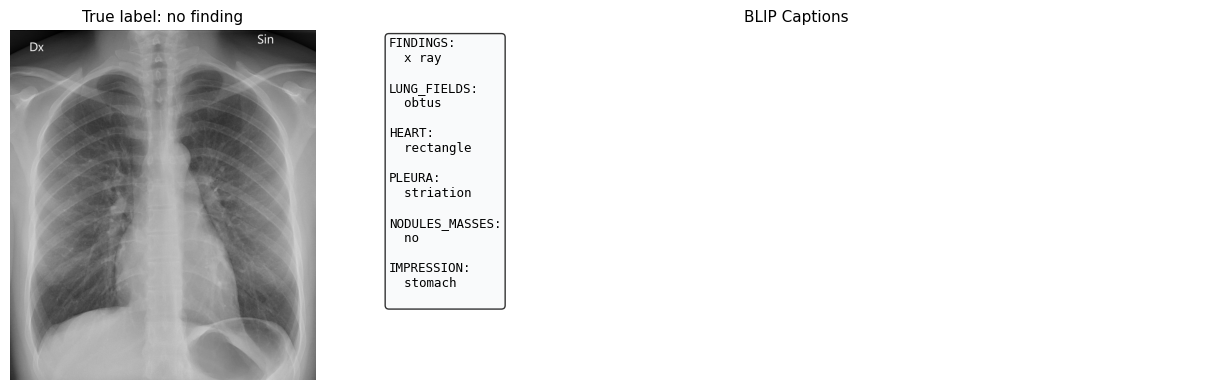

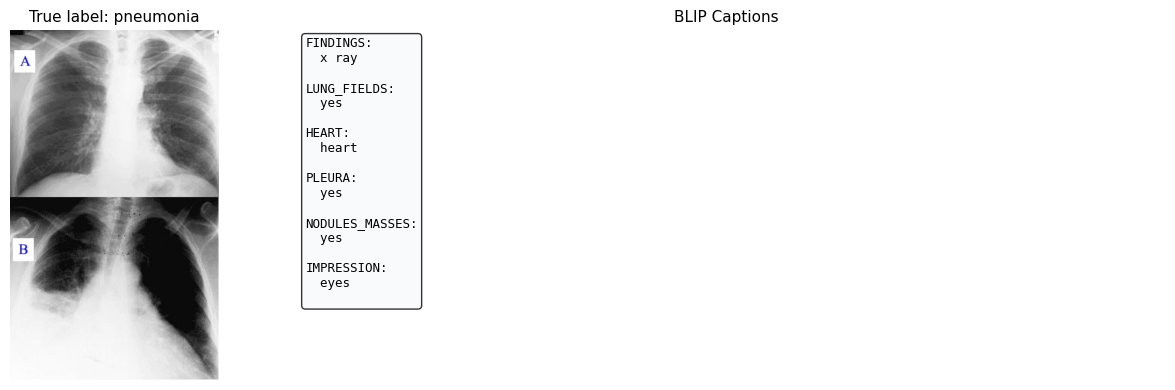

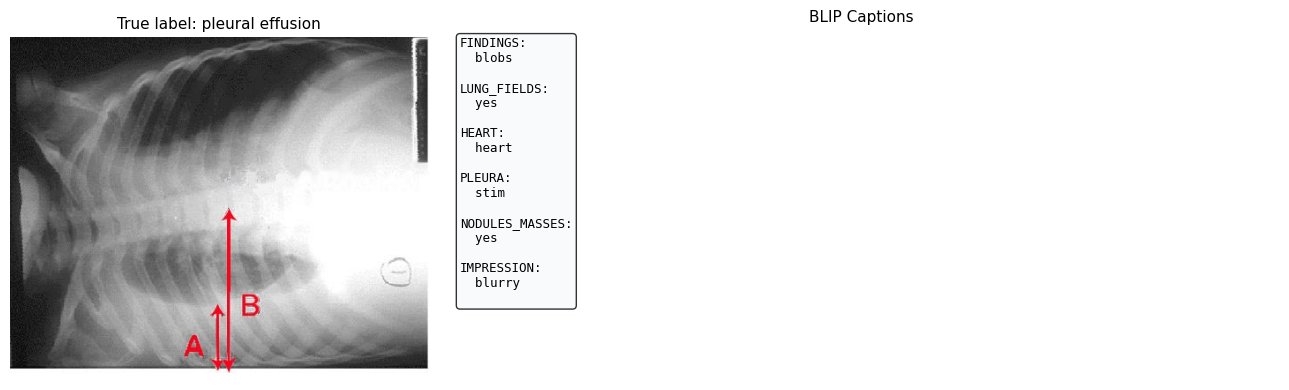

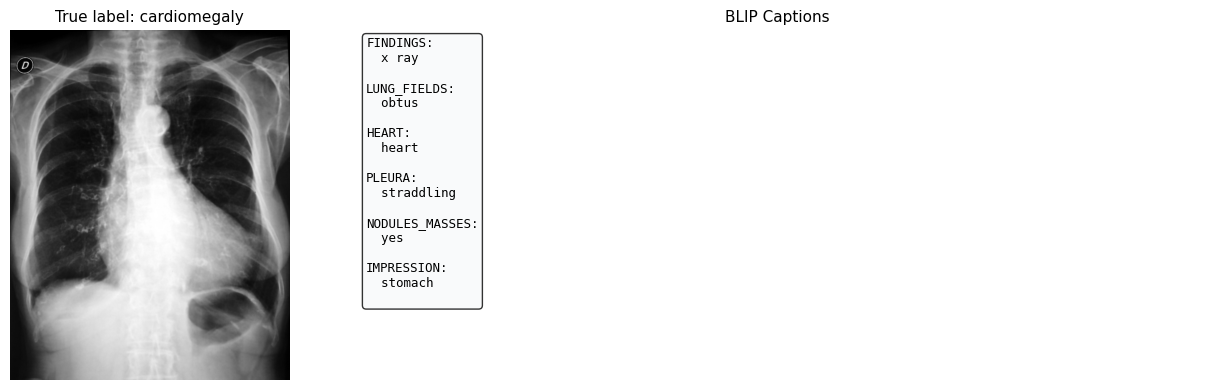

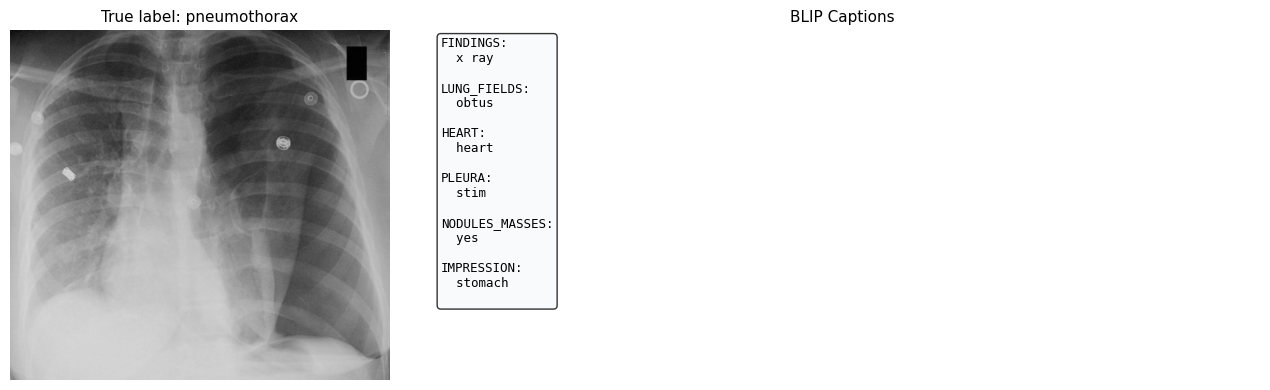

In [6]:
for entry in all_captions:
    fig, (ax_img, ax_text) = plt.subplots(1, 2, figsize=(13, 4),
                                          gridspec_kw={'width_ratios': [1, 2]})
    ax_img.imshow(entry['image'], cmap='gray')
    ax_img.set_title(f"True label: {entry['label']}", fontsize=11)
    ax_img.axis('off')

    text_lines = []
    for section, text in entry['captions'].items():
        text_lines.append(f"{section.upper()}:")
        words = text.split()
        line = ''
        for word in words:
            if len(line) + len(word) + 1 > 60:
                text_lines.append(f'  {line}')
                line = word
            else:
                line = (line + ' ' + word).strip()
        if line:
            text_lines.append(f'  {line}')
        text_lines.append('')

    ax_text.text(0.02, 0.98, '\n'.join(text_lines), transform=ax_text.transAxes,
                 fontsize=9, va='top', family='monospace',
                 bbox=dict(boxstyle='round', facecolor='#f8f9fa', alpha=0.8))
    ax_text.axis('off')
    ax_text.set_title('BLIP Captions', fontsize=11)
    plt.tight_layout()
    plt.show()